In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
df.shape

(9568, 5)

In [6]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

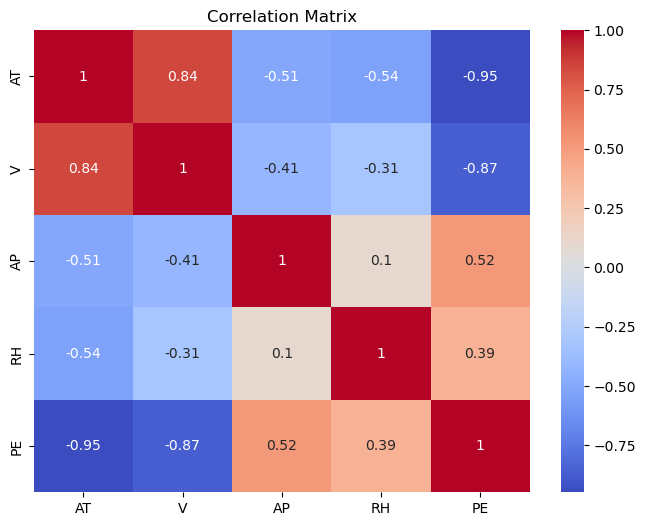

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [10]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [14]:
!pip install torch
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 11.3 MB/s  0:00:07 eta 0:00:010:01:01


In [15]:
type(X_train_scaled)

numpy.ndarray

In [16]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.core.series.Series'>
(7654,)


In [17]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [20]:
# Define ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        
        self.main = nn.Sequential(
            nn.Linear(4, 10), 
            nn.ReLU(),
            nn.Linear(10, 1) 
        )
    def forward(self, x):
        return self.main(x)

model = ANN()

In [38]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [45]:
# Train ANN — mini-batch, 150 epochs
for epoch in range(150):
    model.train()
    for xb, yb in train_loader:      # use DataLoader you already made
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 30 == 0:
        model.eval()
        with torch.no_grad():
            train_loss = criterion(model(X_train_tensor), y_train_tensor)
        print(f'Epoch [{epoch+1}/150], Loss: {train_loss.item():.4f}')

Epoch [30/150], Loss: 5174.0698
Epoch [60/150], Loss: 24.5220
Epoch [90/150], Loss: 20.3614
Epoch [120/150], Loss: 20.2092
Epoch [150/150], Loss: 20.2027


In [46]:
# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Predict and Metrics
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.numpy()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # [cite: 28]
r2 = r2_score(y_test, y_pred) # [cite: 29]

print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

MSE: 18.44, RMSE: 4.29, R2: 0.94


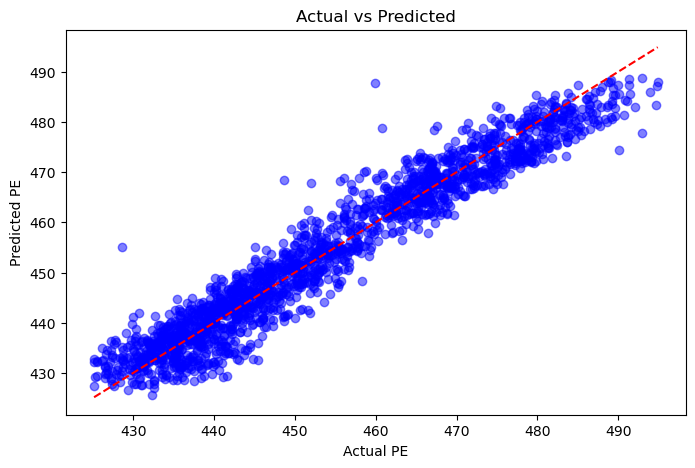

In [47]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual PE")
plt.ylabel("Predicted PE")
plt.title("Actual vs Predicted")
plt.show()

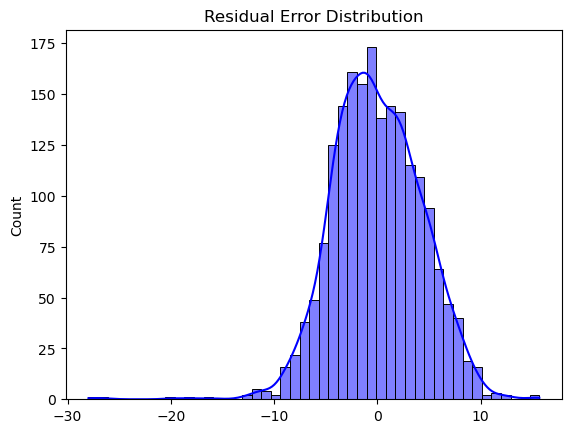

In [48]:
# Residual Error Distribution 
residuals = y_test.values.flatten() - y_pred.flatten()
sns.histplot(residuals, kde=True, color='blue')
plt.title("Residual Error Distribution")
plt.show()

In [49]:
architectures = {
    "Model 1 (5)": [nn.Linear(4, 5), nn.ReLU(), nn.Linear(5, 1)],
    "Model 2 (10)": [nn.Linear(4, 10), nn.ReLU(), nn.Linear(10, 1)],
    "Model 3 (10, 5)": [nn.Linear(4, 10), nn.ReLU(), nn.Linear(10, 5), nn.ReLU(), nn.Linear(5, 1)],
    "Model 4 (20, 10, 5)": [nn.Linear(4, 20), nn.ReLU(), nn.Linear(20, 10), nn.ReLU(), nn.Linear(10, 5), nn.ReLU(), nn.Linear(5, 1)]
}

for name, layers in architectures.items():
    exp_model = nn.Sequential(*layers)
    opt = optim.Adam(exp_model.parameters(), lr=0.001)
    
    # train
    for _ in range(150):                             
        exp_model.train()
        for xb, yb in train_loader:                   
            opt.zero_grad()
            loss = criterion(exp_model(xb), yb)       
            loss.backward()
            opt.step()
    
    # Evaluate (no change needed here)
    exp_model.eval()
    with torch.no_grad():
        p = exp_model(X_test_tensor).numpy()
        print(f"{name} -> RMSE: {np.sqrt(mean_squared_error(y_test, p)):.2f}, R2: {r2_score(y_test, p):.2f}")

Model 1 (5) -> RMSE: 4.39, R2: 0.93
Model 2 (10) -> RMSE: 4.39, R2: 0.93
Model 3 (10, 5) -> RMSE: 4.23, R2: 0.94
Model 4 (20, 10, 5) -> RMSE: 4.14, R2: 0.94


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

ml_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, m in ml_models.items():
    m.fit(X_train_scaled, y_train)
    p = m.predict(X_test_scaled)
    print(f"{name} -> RMSE: {np.sqrt(mean_squared_error(y_test, p)):.2f}, R2: {r2_score(y_test, p):.2f}") 

Linear Regression -> RMSE: 4.43, R2: 0.93
Decision Tree -> RMSE: 4.53, R2: 0.93
Random Forest -> RMSE: 3.18, R2: 0.96
